# Imports

In [1]:
# General util imports
import os

# Math and ML imports
import torch
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

# Visualization imports
from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib.lines import Line2D
from tqdm import tqdm

# Custom imports
from util import download_dataset, create_dataframes, pair_images, get_model_file_path
from custom_datasets import CBISDDSM_RCNN_Dataset

# Kaggle setup and dataset download

In [2]:
download_dataset()

Path to dataset files: C:\Users\nerfb\.cache\kagglehub\datasets\awsaf49\cbis-ddsm-breast-cancer-image-dataset\versions\1
Target directory is not empty. Skipping data copy.


# Create dataframes

In [3]:
df, full_mammograms_df, roi_masks_df, _ = create_dataframes()

print(f"Total ROIs: {len(roi_masks_df)}")
print(roi_masks_df['image_path'].head(5))

Total ROIs: 1696
5     ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
10    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
12    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
18    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
19    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: str


# Pair ROIs with full images

In [4]:
paired_df, merged_df = pair_images(roi_masks_df, full_mammograms_df)

Successfully paired 1696 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 1514 image entries.


In [5]:
paired_df.head(5)

,image_path_full,image_path_roi,PatientID_full,base_id
0,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_00576_LEFT_MLO,Mass-Test_P_00576_LEFT_MLO
1,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_01510_RIGHT_MLO,Mass-Test_P_01510_RIGHT_MLO
2,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_01294_RIGHT_MLO,Mass-Test_P_01294_RIGHT_MLO
3,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Training_P_00281_LEFT_MLO,Mass-Training_P_00281_LEFT_MLO
4,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Training_P_00106_RIGHT_MLO,Mass-Training_P_00106_RIGHT_MLO


# Check dataframe sizes

In [6]:
print("Original df: ", df.shape[0])

print("Mammograms: ", full_mammograms_df.shape[0])
print("ROI masks: ", roi_masks_df.shape[0])

print("Pairs: ", merged_df.shape[0])
print("Entries: ", paired_df.shape[0])

Original df:  5550
Mammograms:  1592
ROI masks:  1696
Pairs:  1618
Entries:  1514


# Transform Functions

In [7]:
# Resize image while keeping aspect ratio, CLAHE, ShiftScaleRotate, random flips, brightness/contrast, and bounding box constraints
train_transform = A.Compose(
    [
        A.LongestMaxSize(1_024),
        A.PadIfNeeded(1_024, 1_024, border_mode=0),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, border_mode=0, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_area=16.0, min_visibility=0.2)
)

# Resize image while keeping aspect ratio and pad to square
test_transform = A.Compose(
    [
        A.LongestMaxSize(1_024),
        A.PadIfNeeded(1_024, 1_024, border_mode=0),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)

C:\Users\nerfb\Downloads\Programs\EUEProjects\FP\Project\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# Visualize the transformed images and bounding boxes

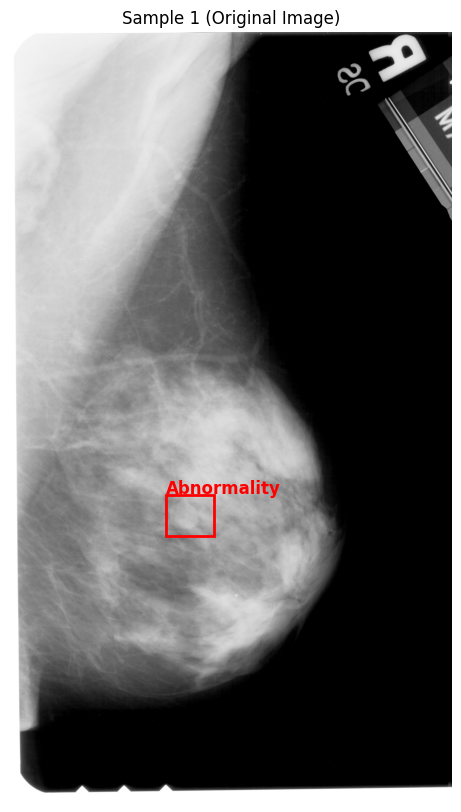

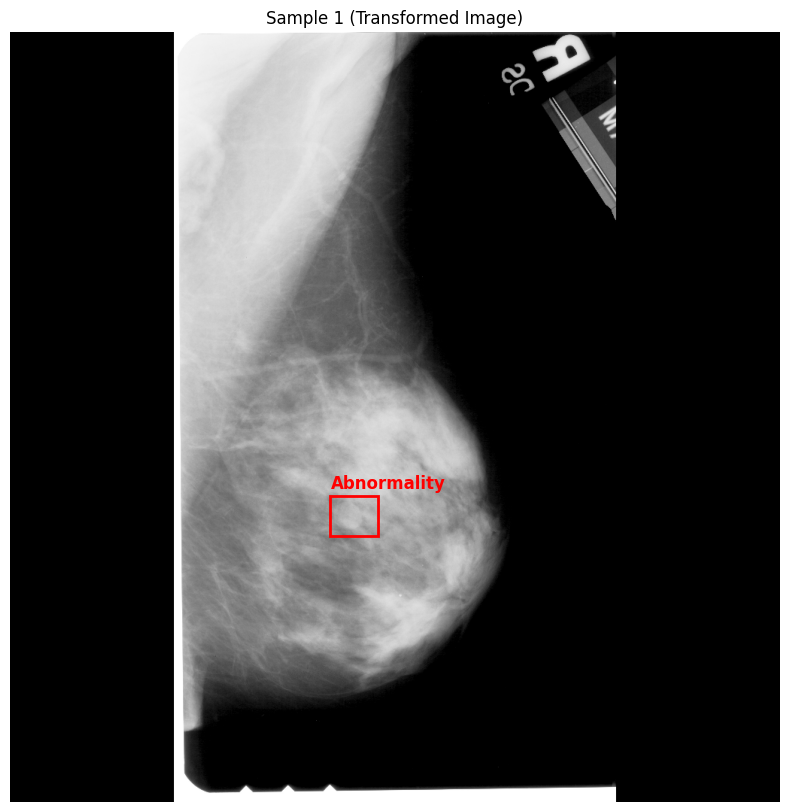

In [8]:
dataset = CBISDDSM_RCNN_Dataset(dataframe=paired_df)

transform_dataset = CBISDDSM_RCNN_Dataset(dataframe=paired_df, transform=test_transform)

check_idx = 1

dataset.visualize_sample(check_idx, title=f"Sample {check_idx} (Original Image)")

transform_dataset.visualize_sample(check_idx, title=f"Sample {check_idx} (Transformed Image)")

# Check image with multiple ROIs

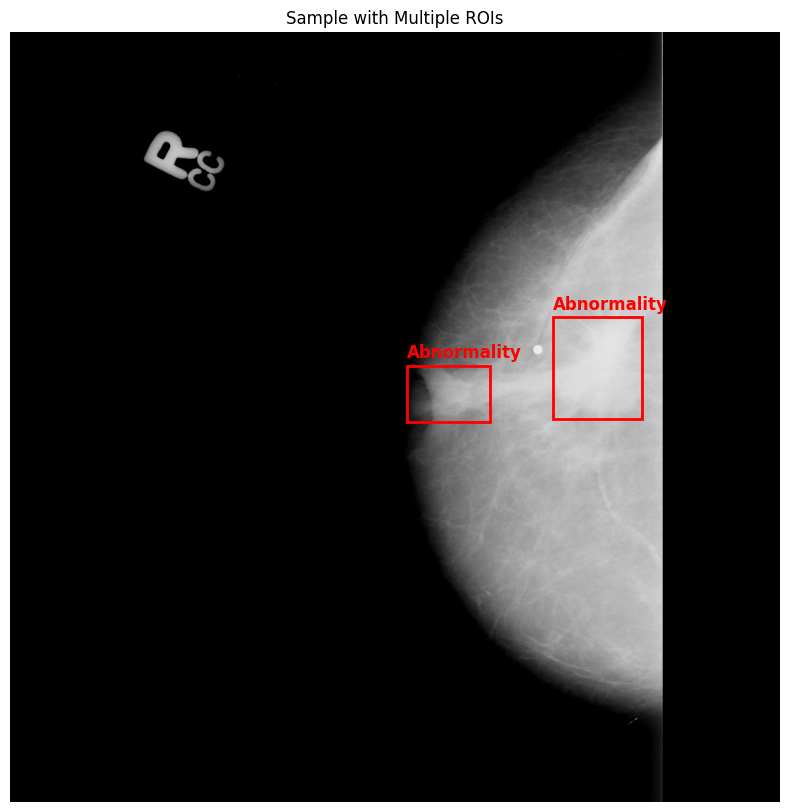

In [9]:
transform_dataset.visualize_sample(360, title=f"Sample with Multiple ROIs") # idx found through the dataset exploration notebook

# Train test split

In [10]:
# Split based on patient IDs
unique_patients = paired_df['PatientID_full'].unique()
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

In [11]:
train_df = paired_df[paired_df['PatientID_full'].isin(train_patients)].copy()
test_df = paired_df[paired_df['PatientID_full'].isin(test_patients)].copy()

In [12]:
train_dataset = CBISDDSM_RCNN_Dataset(dataframe=train_df, transform=train_transform)

test_dataset = CBISDDSM_RCNN_Dataset(dataframe=test_df, transform=test_transform)

In [13]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

# Initialize model and check for cuda

In [15]:
def get_model(num_classes: int) -> FasterRCNN:
    """
    Creates and returns a Faster R-CNN object detection model based on a ResNet-50 backbone.

    The configured model uses the Faster R-CNN framework with a ResNet-50 backbone, which is pre-trained
    on ImageNet/COCO dataset to initialize the weights. It incorporates a custom AnchorGenerator
    tailored to CBIS-DDSM lesion morphology across FPN levels, enables deep backbone fine-tuning
    (trainable_backbone_layers=5), and configures RoI detection parameters (box_score_thresh=0.05,
    box_nms_thresh=0.5, box_detections_per_img=100) optimized for radiographic lesion sensitivity.

    :param num_classes: The number of classes including background class for the object detection model.
    :type num_classes: int
    :return: A Faster R-CNN model configured for the given number of classes.
    :rtype: FasterRCNN
    """

    # Custom anchor generator tailored to CBIS-DDSM mass lesion morphology
    anchor_generator = AnchorGenerator(
        sizes=((16, 32), (32, 64), (64, 128), (128, 256), (256, 512)),
        aspect_ratios=((0.5, 0.75, 1.0, 1.33, 2.0),) * 5
    )

    # Base model with custom RPN anchor generator, fully fine-tunable backbone, and tuned RoI detection parameters
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=torchvision.models.ResNet50_Weights.DEFAULT,
        trainable_backbone_layers=5,
        rpn_anchor_generator=anchor_generator,
        box_score_thresh=0.05,
        box_nms_thresh=0.5,
        box_detections_per_img=100
    )

    # Configure the model for the specified number of classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


num_classes = 2  # Background or abnormality
model = get_model(num_classes)

# Use CUDA if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Using device: {device}")

# Verify parameter trainability and model capacity
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,} | Trainable: {trainable_params:,} ({trainable_params / total_params:.1%})")

Using device: cuda
Total parameters: 41,308,156 | Trainable: 41,308,156 (100.0%)


In [16]:
# Ensure the checkpoint directory exists
checkpoint_dir = '../models/Faster_RCNN/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

In [17]:
# Ensure the completed model directory exists
completed_dir = '../models/Faster_RCNN/completed'
os.makedirs(completed_dir, exist_ok=True)

# Check for trained models

In [18]:
completed_path = None

if len(os.listdir(completed_dir)) > 0:
    completed_path = get_model_file_path("Completed model directory is not empty. Do you want to use saved model? (y/n): ",
                                         "../models/Faster_RCNN/completed")

    if completed_path:
        print(f"Using saved model from {completed_path}")
    else:
        print("No model file selected. Starting training from scratch.")

No model file selected. Starting training from scratch.


# Check for checkpoints

In [21]:
resume_path = None

if not completed_path and len(os.listdir(checkpoint_dir)) > 0:
    resume_path = get_model_file_path("Checkpoint directory is not empty. Do you want to resume training? (y/n): ",
                                      "../models/Faster_RCNN/checkpoints")

    if resume_path:
        print(f"Resuming training from checkpoint {resume_path}")
    else:
        print("No checkpoint file selected. Starting training from scratch.")

Resuming training from checkpoint C:/Users/nerfb/Downloads/Programs/EUEProjects/FP/Project/models/Faster_RCNN/checkpoints/checkpoint_9.pth


# Train Model

In [23]:
def evaluate_loss(model: FasterRCNN, data_loader: DataLoader, device: torch.device) -> float:
    """
    Computes total validation loss on the provided dataloader without computing gradients.
    In torchvision Faster R-CNN, model.train() is required to output loss dictionaries.
    """
    model.train()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', enabled=True):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()
    return val_loss / len(data_loader) if len(data_loader) > 0 else 0.0


def evaluate_map(model: FasterRCNN, data_loader: DataLoader, device: torch.device) -> dict:
    """
    Computes standard mAP detection metrics (COCO & PASCAL VOC) on the provided dataloader.
    """
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    model.eval()
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(image.to(device) for image in images)
            predictions = model(images)

            formatted_predictions = [
                {
                    'boxes': p['boxes'].cpu(),
                    'scores': p['scores'].cpu(),
                    'labels': p['labels'].cpu()
                }
                for p in predictions
            ]
            formatted_targets = [
                {
                    'boxes': t['boxes'].cpu(),
                    'labels': t['labels'].cpu()
                }
                for t in targets
            ]
            metric.update(formatted_predictions, formatted_targets)

    return metric.compute()


# Differential learning rates: lower for pretrained ResNet-50 backbone, higher for detection heads
backbone_params = [p for n, p in model.named_parameters() if 'backbone' in n and p.requires_grad]
head_params = [p for n, p in model.named_parameters() if 'backbone' not in n and p.requires_grad]

optimizer = torch.optim.AdamW(
    [
        {'params': backbone_params, 'lr': 1e-4},
        {'params': head_params, 'lr': 5e-4},
    ],
    weight_decay=1e-4
)

num_epochs = 15
warmup_epochs = 1

# Warmup + Cosine Annealing learning rate schedule
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_epochs
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, num_epochs - warmup_epochs),
    eta_min=1e-6
)
lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs]
)

start_epoch = 0
best_val_map_50 = -1.0
best_val_map = -1.0
best_epoch = -1

history = {
    'train_loss': [],
    'val_loss': [],
    'val_map': [],
    'val_map_50': [],
    'lr': []
}

# No need for training if using an already trained model
if completed_path:
    if os.path.exists(completed_path):
        print(f"Loading model from {completed_path}")
        saved = torch.load(completed_path, map_location=device)
        if isinstance(saved, dict) and 'model_state_dict' in saved:
            model.load_state_dict(saved['model_state_dict'])
            if 'history' in saved:
                history = saved['history']
        else:
            model.load_state_dict(saved)
        model.eval()
        print("Model loaded successfully.")
elif resume_path:
    if os.path.exists(resume_path):
        print(f"Loading checkpoint from {resume_path}")

        # Load model from checkpoint
        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if 'lr_scheduler_state_dict' in checkpoint:
            lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
        if 'history' in checkpoint:
            history = checkpoint['history']
        if 'best_val_map_50' in checkpoint:
            best_val_map_50 = checkpoint['best_val_map_50']
        if 'best_val_map' in checkpoint:
            best_val_map = checkpoint['best_val_map']
        start_epoch = checkpoint['epoch']

        print(f"Resuming training from epoch {start_epoch}")
    else:
        raise FileNotFoundError(f"Checkpoint file {resume_path} not found.")

if not completed_path:
    # Use autocast for mixed precision training (AMP) for faster training
    scaler = GradScaler()
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0.0

        for i, (images, targets) in enumerate(train_loader):
            # Move images and targets to the appropriate device (GPU if available or CPU otherwise)
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass and loss calculation
            with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', enabled=True):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())

            # Backward pass and optimization step with gradient clipping
            scaler.scale(losses).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += losses.item()

            if i % 10 == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}] | Batch [{i}/{len(train_loader)}] | Loss: {losses.item():.4f}")

        avg_train_loss = epoch_loss / len(train_loader)
        current_lr = optimizer.param_groups[0]['lr']
        lr_scheduler.step()

        # Epoch-level validation loop (loss + mAP metrics)
        print()
        print(f"Evaluating epoch {epoch + 1} on validation set...")
        val_loss = evaluate_loss(model, test_loader, device)
        val_metrics = evaluate_map(model, test_loader, device)
        val_map = val_metrics['map'].item()
        val_map_50 = val_metrics['map_50'].item()

        # Record history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_map)
        history['val_map_50'].append(val_map_50)
        history['lr'].append(current_lr)

        print(f"--- Epoch {epoch + 1}/{num_epochs} Summary ---")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Val mAP@0.50:0.95 (COCO): {val_map:.4f} | Val mAP@0.50 (VOC): {val_map_50:.4f} | LR: {current_lr:.6f}")

        # Best-checkpoint selection based on validation detection performance (mAP@0.50)
        is_best = val_map_50 > best_val_map_50
        if is_best:
            best_val_map_50 = val_map_50
            best_val_map = val_map
            best_epoch = epoch + 1
            best_checkpoint_path = os.path.join(checkpoint_dir, 'rcnn_best_model.pth')
            best_checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'lr_scheduler_state_dict': lr_scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': val_loss,
                'val_map': val_map,
                'val_map_50': val_map_50,
                'history': history,
                'best_val_map_50': best_val_map_50,
                'best_val_map': best_val_map
            }
            torch.save(best_checkpoint, best_checkpoint_path)
            # Also save standalone weights to completed directory
            torch.save(model.state_dict(), os.path.join(completed_dir, 'rcnn_best_model.pth'))
            print(f">>> [BEST MODEL UPDATED] Saved checkpoint to {best_checkpoint_path} (mAP@0.50: {val_map_50:.4f})")

        # Save regular epoch checkpoint
        checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_{epoch + 1}.pth')
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'lr_scheduler_state_dict': lr_scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': val_loss,
            'val_map': val_map,
            'val_map_50': val_map_50,
            'history': history,
            'best_val_map_50': best_val_map_50,
            'best_val_map': best_val_map
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")
        print()

    print()
    print(f"Training complete. Peak validation performance: mAP@0.50 = {best_val_map_50:.4f} at epoch {best_epoch}.")

Loading checkpoint from C:/Users/nerfb/Downloads/Programs/EUEProjects/FP/Project/models/Faster_RCNN/checkpoints/checkpoint_9.pth
Resuming training from epoch 8
Epoch [9/15] | Batch [0/303] | Loss: 0.1545
Epoch [9/15] | Batch [10/303] | Loss: 0.1914
Epoch [9/15] | Batch [20/303] | Loss: 0.3051
Epoch [9/15] | Batch [30/303] | Loss: 0.2678
Epoch [9/15] | Batch [40/303] | Loss: 0.1652
Epoch [9/15] | Batch [50/303] | Loss: 0.2469
Epoch [9/15] | Batch [60/303] | Loss: 0.2748
Epoch [9/15] | Batch [70/303] | Loss: 0.1804
Epoch [9/15] | Batch [80/303] | Loss: 0.1995
Epoch [9/15] | Batch [90/303] | Loss: 0.2430
Epoch [9/15] | Batch [100/303] | Loss: 0.4188
Epoch [9/15] | Batch [110/303] | Loss: 0.2572
Epoch [9/15] | Batch [120/303] | Loss: 0.2094
Epoch [9/15] | Batch [130/303] | Loss: 0.2525
Epoch [9/15] | Batch [140/303] | Loss: 0.2495
Epoch [9/15] | Batch [150/303] | Loss: 0.2024
Epoch [9/15] | Batch [160/303] | Loss: 0.2990
Epoch [9/15] | Batch [170/303] | Loss: 0.2376
Epoch [9/15] | Batch [1

In [24]:
# Save the trained model only after completing training
if not completed_path:
    model_save_path = os.path.join(completed_dir, 'Completed_Training.pth')
    torch.save(model.state_dict(), model_save_path)
    print(f"Final epoch model weights saved to {model_save_path}")

    best_weights_path = os.path.join(completed_dir, 'rcnn_best_model.pth')
    if os.path.exists(best_weights_path):
        print(f"Best validation model weights saved to {best_weights_path}")

Final epoch model weights saved to ../models/Faster_RCNN/completed\Completed_Training.pth
Best validation model weights saved to ../models/Faster_RCNN/completed\rcnn_best_model.pth


# Plot Training and Validation Metrics

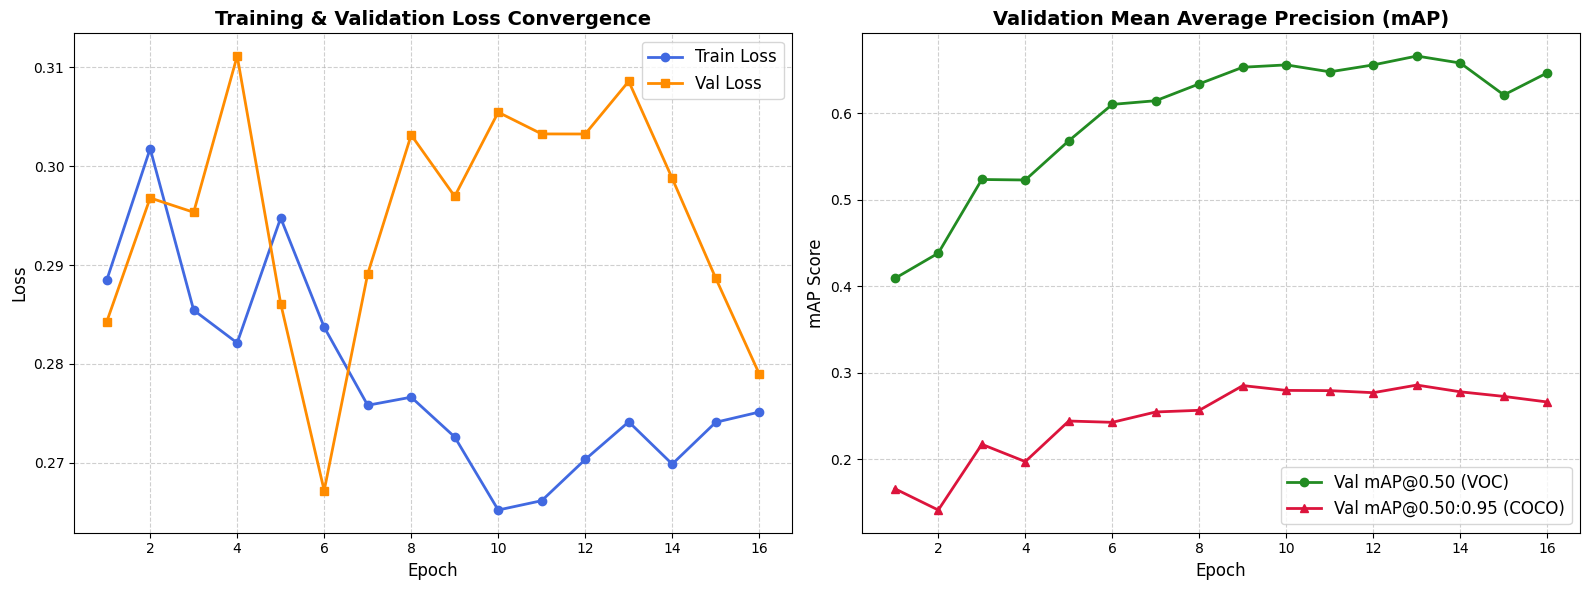

In [25]:
# Plot training & validation loss and validation mAP progression
if history['train_loss'] and history['val_loss']:
    epochs_range = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Loss curves
    axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue', marker='o', linewidth=2)
    axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='darkorange', marker='s', linewidth=2)
    axes[0].set_title('Training & Validation Loss Convergence', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(fontsize=12)

    # mAP curves
    axes[1].plot(epochs_range, history['val_map_50'], label='Val mAP@0.50 (VOC)', color='forestgreen', marker='o', linewidth=2)
    axes[1].plot(epochs_range, history['val_map'], label='Val mAP@0.50:0.95 (COCO)', color='crimson', marker='^', linewidth=2)
    axes[1].set_title('Validation Mean Average Precision (mAP)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('mAP Score', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("No training history available to plot.")

# Visualize predicted image

In [26]:
def test_and_visualize(
    model: FasterRCNN,
    test_loader: DataLoader,
    device: torch.device,
    confidence_threshold: float = 0.2,
    num_samples: int = 1,
    start_idx: int = 0
) -> None:
    """
    Test and visualize Faster R-CNN mass detection predictions on test mammograms.
    Overlays ground truth lesions (Red) and predicted lesions (Green) with confidence scores
    and clear bounding box annotations.

    :param model: Trained Faster R-CNN model
    :param test_loader: DataLoader object supplying test mammograms and ground truth targets
    :param device: PyTorch device (CPU or CUDA)
    :param confidence_threshold: Minimum score threshold for displaying predicted boxes
    :param num_samples: Number of images from the batch to visualize
    :param start_idx: Starting image index within the first batch
    :return: None
    """
    model.eval()

    images, targets = next(iter(test_loader))
    images_dev = list(img.to(device) for img in images)

    with torch.no_grad():
        predictions = model(images_dev)

    for i in range(start_idx, min(start_idx + num_samples, len(images))):
        img_np = images[i].cpu().permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)

        fig, ax = plt.subplots(1, figsize=(10, 10))

        if img_np.shape[-1] == 1:
            ax.imshow(img_np.squeeze(-1), cmap='gray')
        else:
            ax.imshow(img_np)

        # Ground Truth Boxes (Red)
        true_boxes = targets[i]['boxes'].cpu().numpy()
        for box in true_boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin), xmax - xmin, ymax - ymin,
                linewidth=2.5, edgecolor='#FF2222', facecolor='none', linestyle='-'
            )
            ax.add_patch(rect)
            ax.text(
                xmin, max(ymin - 6, 12), "Actual Mass",
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='square,pad=0.2', fc='#FF2222', ec='none', alpha=0.8)
            )

        # Predicted Boxes (Green)
        pred_boxes = predictions[i]['boxes'].cpu().numpy()
        pred_scores = predictions[i]['scores'].cpu().numpy()

        detected_count = 0
        for box, score in zip(pred_boxes, pred_scores):
            if score >= confidence_threshold:
                detected_count += 1
                xmin, ymin, xmax, ymax = box
                rect = patches.Rectangle(
                    (xmin, ymin), xmax - xmin, ymax - ymin,
                    linewidth=2.5, edgecolor='#00FF66', facecolor='none', linestyle='--'
                )
                ax.add_patch(rect)
                ax.text(
                    xmin, ymax + 14, f"Pred: {score:.2f}",
                    color='black', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='square,pad=0.2', fc='#00FF66', ec='none', alpha=0.85)
                )

        ax.set_title(
            f"Test Mammogram #{i + 1} | Actual ROIs: {len(true_boxes)} | Predictions (>= {confidence_threshold:.2f}): {detected_count}",
            fontsize=13, fontweight='bold'
        )
        ax.axis('off')

        legend_elements = [
            Line2D([0], [0], color='#FF2222', lw=2.5, label='Actual Mass (Ground Truth)'),
            Line2D([0], [0], color='#00FF66', lw=2.5, linestyle='--', label=f'Predicted Mass (Score >= {confidence_threshold:.2f})')
        ]
        ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

        plt.tight_layout()
        plt.show()

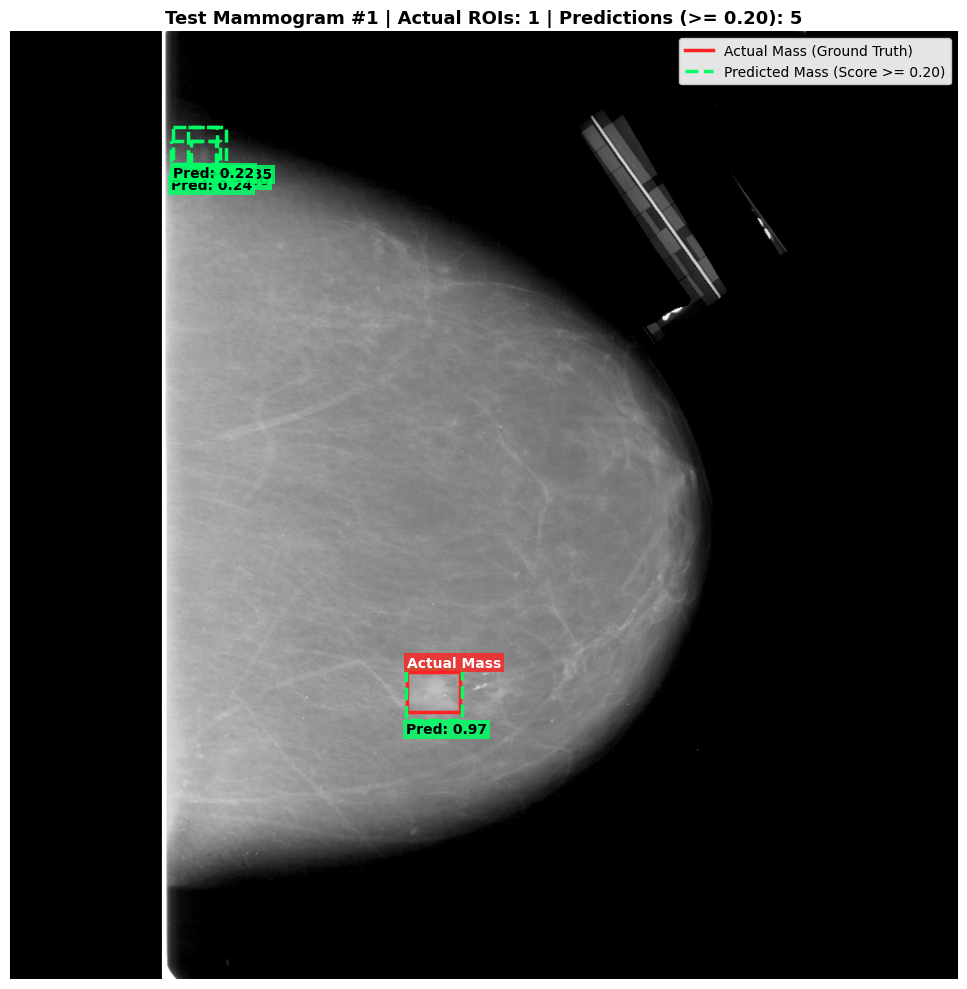

In [27]:
test_and_visualize(model, test_loader, device, confidence_threshold=0.2, num_samples=1)

# Load Best Model Checkpoint and Calculate Test Set mAP

In [28]:
# Load the best performing checkpoint weights for final evaluation
best_model_weights = os.path.join(completed_dir, 'rcnn_best_model.pth')
best_checkpoint = os.path.join(checkpoint_dir, 'rcnn_best_model.pth')

if os.path.exists(best_model_weights):
    print(f"Loading best model weights from {best_model_weights}")
    saved = torch.load(best_model_weights, map_location=device)
    if isinstance(saved, dict) and 'model_state_dict' in saved:
        model.load_state_dict(saved['model_state_dict'])
    else:
        model.load_state_dict(saved)
elif os.path.exists(best_checkpoint):
    print(f"Loading best checkpoint from {best_checkpoint}")
    chk = torch.load(best_checkpoint, map_location=device)
    model.load_state_dict(chk['model_state_dict'])
elif completed_path and os.path.exists(completed_path):
    print(f"Evaluating currently loaded model from {completed_path}")
else:
    print("Using current in-memory model weights for evaluation.")

model.eval()


def calculate_test_map(model: FasterRCNN, test_loader: DataLoader, device: torch.device) -> dict:
    """
    Computes comprehensive detection metrics (COCO & PASCAL VOC standards) on the test dataset.
    """
    print("Calculating test set mAP...")
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    model.eval()

    print(f"Evaluating over {len(test_loader)} batches.")
    with torch.no_grad():
        for imgs, targets in tqdm(test_loader):
            imgs = list(img.to(device) for img in imgs)

            predictions = model(imgs)

            formatted_predictions = [
                {
                    'boxes': p['boxes'].cpu(),
                    'scores': p['scores'].cpu(),
                    'labels': p['labels'].cpu()
                }
                for p in predictions
            ]
            formatted_targets = [
                {
                    'boxes': t['boxes'].cpu(),
                    'labels': t['labels'].cpu()
                }
                for t in targets
            ]

            metric.update(formatted_predictions, formatted_targets)

    print("Computing final detection metrics...")
    results = metric.compute()
    print("Done.")
    print()

    return results

Loading best model weights from ../models/Faster_RCNN/completed\rcnn_best_model.pth


In [29]:
map_results = calculate_test_map(model, test_loader, device)

Calculating test set mAP...
Evaluating over 76 batches.


100%|██████████| 76/76 [01:51<00:00,  1.47s/it]

Computing final detection metrics...
Done.



In [31]:
# Comprehensive metrics display
print("========================== FINAL TEST EVALUATION METRICS ==========================")
print(f"mAP @ IoU=0.50:0.95 (COCO Standard):       {map_results['map'].item():.4f}")
print(f"mAP @ IoU=0.50      (PASCAL VOC Standard): {map_results['map_50'].item():.4f}")
print(f"mAP @ IoU=0.75      (Strict IoU):          {map_results['map_75'].item():.4f}")
print(f"mAP (Small Lesions):                       {map_results['map_small'].item():.4f}")
print(f"mAP (Medium Lesions):                      {map_results['map_medium'].item():.4f}")
print(f"mAP (Large Lesions):                       {map_results['map_large'].item():.4f}")
print(f"mAR @ max_detections=1:                    {map_results['mar_1'].item():.4f}")
print(f"mAR @ max_detections=10:                   {map_results['mar_10'].item():.4f}")
print(f"mAR @ max_detections=100:                  {map_results['mar_100'].item():.4f}")
if 'map_per_class' in map_results and map_results['map_per_class'].numel() > 0:
    if map_results['map_per_class'].ndim == 0:
        print(f"mAP for Class 1 (Mass Lesion):             {map_results['map_per_class'].item():.4f}")
    else:
        for cls_idx, cls_map in enumerate(map_results['map_per_class']):
            print(f"mAP for Class {cls_idx + 1} (Mass Lesion):             {cls_map.item():.4f}")
print("==================================================================================")

========================== FINAL TEST EVALUATION METRICS ==========================
mAP @ IoU=0.50:0.95 (COCO Standard):       0.2859
mAP @ IoU=0.50      (PASCAL VOC Standard): 0.6659
mAP @ IoU=0.75      (Strict IoU):          0.1890
mAP (Small Lesions):                       0.1540
mAP (Medium Lesions):                      0.2905
mAP (Large Lesions):                       0.3219
mAR @ max_detections=1:                    0.3188
mAR @ max_detections=10:                   0.4611
mAR @ max_detections=100:                  0.4611
mAP for Class 1 (Mass Lesion):             0.2859
